In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/atilsamancioglu/MachineLearningNotebooks/refs/heads/main/20-digitalskysurvey.csv")

In [3]:
df.head()

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,class,redshift,plate,mjd,fiberid
0,1.237650e+18,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,3.722360e+18,STAR,-0.000009,3306,54922,491
1,1.237650e+18,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,3.638140e+17,STAR,-0.000055,323,51615,541
2,1.237650e+18,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,3.232740e+17,GALAXY,0.123111,287,52023,513
3,1.237650e+18,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752,301,4,269,3.722370e+18,STAR,-0.000111,3306,54922,510
4,1.237650e+18,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752,301,4,269,3.722370e+18,STAR,0.000590,3306,54922,512


In [4]:
columns_to_drop = ["objid", "specobjid", "rerun", "camcol", "field", "run"] # burada işimize yaramayacak kolonları drop edildi(data açıklamasına bakılarak karar verildi)

In [5]:
df.drop(columns_to_drop, axis=1, inplace=True)

In [6]:
df.head()

,ra,dec,u,g,r,i,z,class,redshift,plate,mjd,fiberid
0,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,STAR,-0.000009,3306,54922,491
1,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,STAR,-0.000055,323,51615,541
2,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,GALAXY,0.123111,287,52023,513
3,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,STAR,-0.000111,3306,54922,510
4,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,STAR,0.000590,3306,54922,512


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ra        10000 non-null  float64
 1   dec       10000 non-null  float64
 2   u         10000 non-null  float64
 3   g         10000 non-null  float64
 4   r         10000 non-null  float64
 5   i         10000 non-null  float64
 6   z         10000 non-null  float64
 7   class     10000 non-null  object 
 8   redshift  10000 non-null  float64
 9   plate     10000 non-null  int64  
 10  mjd       10000 non-null  int64  
 11  fiberid   10000 non-null  int64  
dtypes: float64(8), int64(3), object(1)
memory usage: 937.6+ KB


In [8]:
df['class'].value_counts()

,count
class,
GALAXY,4998
STAR,4152
QSO,850


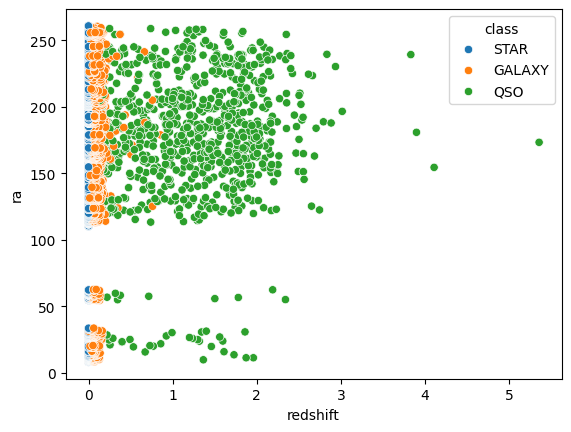

In [9]:
sns.scatterplot(data=df, x='redshift', y='ra', hue="class")
plt.show()
#redshift önemliymiş

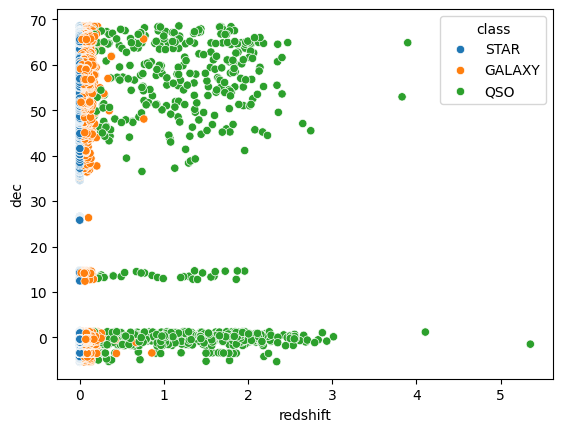

In [10]:
sns.scatterplot(data=df, x='redshift', y='dec', hue="class")
plt.show() #buda bariz bir şekilde ayırıyor

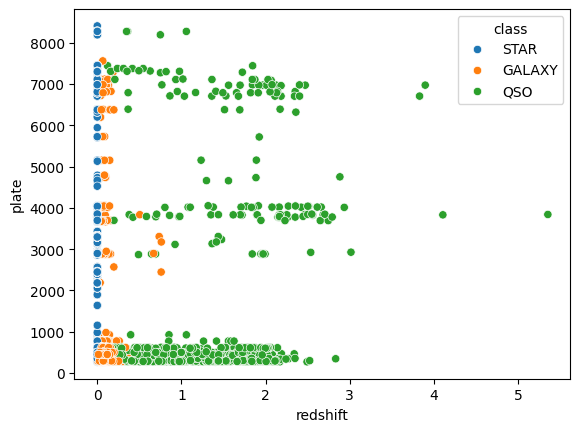

In [11]:
sns.scatterplot(data=df, x='redshift', y='plate', hue="class")
plt.show()

In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['class'] = le.fit_transform(df['class']) # classı encode ettik

In [13]:
df.head()

,ra,dec,u,g,r,i,z,class,redshift,plate,mjd,fiberid
0,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,2,-0.000009,3306,54922,491
1,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,2,-0.000055,323,51615,541
2,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,0,0.123111,287,52023,513
3,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,2,-0.000111,3306,54922,510
4,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,2,0.000590,3306,54922,512


In [14]:
df.corr()

,ra,dec,u,g,r,i,z,class,redshift,plate,mjd,fiberid
ra,1.000000,0.003596,0.031238,0.043909,0.047103,0.045731,0.042950,-0.043219,0.030307,-0.095329,-0.086887,0.057485
dec,0.003596,1.000000,0.035279,0.061875,0.063404,0.058292,0.056870,-0.058918,0.067021,0.088342,0.066147,0.155012
u,0.031238,0.035279,1.000000,0.849232,0.692379,0.602630,0.551483,-0.269044,0.163741,-0.129430,-0.168793,0.011301
g,0.043909,0.061875,0.849232,1.000000,0.958106,0.907419,0.879622,-0.099212,0.407576,-0.054981,-0.092772,0.047187
r,0.047103,0.063404,0.692379,0.958106,1.000000,0.977672,0.969197,0.049628,0.441080,0.019787,-0.009345,0.061081
i,0.045731,0.058292,0.602630,0.907419,0.977672,1.000000,0.981507,0.146791,0.431450,0.072958,0.050896,0.069977
z,0.042950,0.056870,0.551483,0.879622,0.969197,0.981507,1.000000,0.215758,0.424034,0.112397,0.095658,0.067980
class,-0.043219,-0.058918,-0.269044,-0.099212,0.049628,0.146791,0.215758,1.000000,-0.075510,0.585495,0.648768,0.053593
redshift,0.030307,0.067021,0.163741,0.407576,0.441080,0.431450,0.424034,-0.075510,1.000000,-0.038091,-0.057957,0.046532
plate,-0.095329,0.088342,-0.129430,-0.054981,0.019787,0.072958,0.112397,0.585495,-0.038091,1.000000,0.966881,0.229811


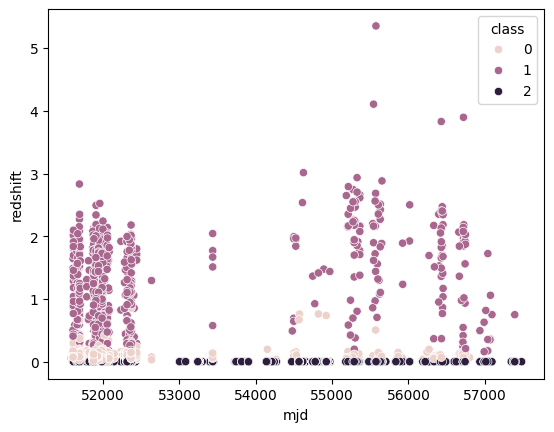

In [15]:
sns.scatterplot(data=df, x='mjd', y='redshift', hue="class")
plt.show()

In [16]:
sns.pairplot(df, hue="class")
plt.show()

Output hidden; open in https://colab.research.google.com to view.

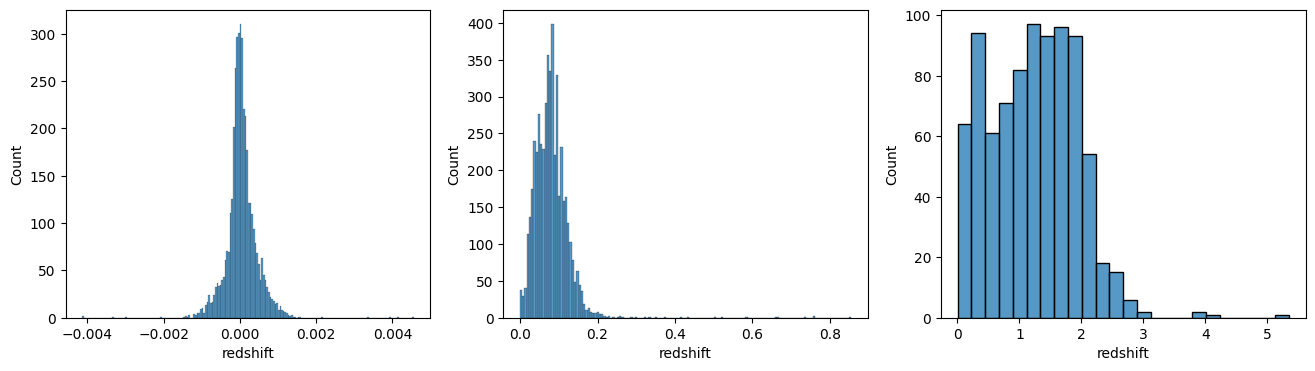

In [19]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16,4))
ax = sns.histplot(df[df['class'] == 2].redshift, ax= axes[0])
ax = sns.histplot(df[df['class'] == 0].redshift, ax= axes[1])
ax = sns.histplot(df[df['class'] == 1].redshift, ax= axes[2])
plt.show()

In [20]:
df['class'].value_counts()

,count
class,
0,4998
2,4152
1,850


In [21]:
X = df.drop('class', axis=1)
y = df['class']

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=15)

In [25]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [26]:
!pip install xgboost

In [27]:
from xgboost import XGBClassifier

In [29]:
xgb = XGBClassifier(n_estimators = 100)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [31]:
print("confusion matrix: \n", confusion_matrix(y_pred, y_test))
print("accuracy score: ", accuracy_score(y_pred, y_test))
print("classification report: \n", classification_report(y_pred, y_test))

confusion matrix: 
 [[1667   18    2]
 [  13  252    0]
 [   7    1 1340]]
accuracy score:  0.9875757575757576
classification report: 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1687
           1       0.93      0.95      0.94       265
           2       1.00      0.99      1.00      1348

    accuracy                           0.99      3300
   macro avg       0.97      0.98      0.97      3300
weighted avg       0.99      0.99      0.99      3300



In [32]:
#hyperparameter tuning

In [33]:
params = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.1],
    "max_depth": [5,8,12,20,30],
    "colsample_bytree": [0.3, 0.4, 0.5, 0.8, 1]
}

In [34]:
from sklearn.model_selection import GridSearchCV

In [35]:
grid = GridSearchCV(estimator=XGBClassifier(), param_grid= params, cv=5, n_jobs=-1)

In [ ]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.3, 0.4, 0.5, 0.8, 1],
                         'learning_rate': [0.01, 0.1],
                         'max_depth': [5, 8, 12, 20, 30],
                         'n_estimators': [100, 200, 300, 500]})

In [ ]:
grid.best_params_

In [ ]:
y_pred = grid.predict(X_test)

In [ ]:
print("confusion matrix: \n", confusion_matrix(y_pred, y_test))
print("accuracy score: ", accuracy_score(y_pred, y_test))
print("classification report: \n", classification_report(y_pred, y_test))